In [6]:
import sys
sys.path.append('/kaggle/input/monai/pytorch/default/1/')

In [7]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 75.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existi

In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
from tqdm import tqdm
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Spacingd, ScaleIntensityRanged,
    CropForegroundd, Orientationd, RandFlipd, RandAffined,
    RandScaleIntensityd, RandShiftIntensityd, ToTensord
)
from monai.data import Dataset, DataLoader

# Define directories
train_dir = "/kaggle/input/soham/BRATS_2018/train"
val_dir = "/kaggle/input/soham/BRATS_2018/Val"
test_dir = "/kaggle/input/soham/BRATS_2018/test"

# Subdirs
train_images_dir = os.path.join(train_dir, "images")
train_labels_dir = os.path.join(train_dir, "mask")
val_images_dir = os.path.join(val_dir, "images")
val_labels_dir = os.path.join(val_dir, "mask")
test_images_dir = os.path.join(test_dir, "images")
test_labels_dir = os.path.join(test_dir, "mask")

# File lists
train_image_files = sorted(glob.glob(f"{train_images_dir}/*.nii"))
train_label_files = sorted(glob.glob(f"{train_labels_dir}/*.nii"))
val_image_files = sorted(glob.glob(f"{val_images_dir}/*.nii"))
val_label_files = sorted(glob.glob(f"{val_labels_dir}/*.nii"))
test_image_files = sorted(glob.glob(f"{test_images_dir}/*.nii"))
test_label_files = sorted(glob.glob(f"{test_labels_dir}/*.nii"))

# Matching check
if len(train_image_files) != len(train_label_files):
    raise ValueError(f"Train images and labels count mismatch.")
if len(val_image_files) != len(val_label_files):
    raise ValueError(f"Val images and labels count mismatch.")
if len(test_image_files) != len(test_label_files):
    raise ValueError(f"Test images and labels count mismatch.")

# Create file dictionaries
train_files = [{"image": img, "label": lbl} for img, lbl in zip(train_image_files, train_label_files)]
val_files = [{"image": img, "label": lbl} for img, lbl in zip(val_image_files, val_label_files)]
test_files = [{"image": img, "label": lbl} for img, lbl in zip(test_image_files, test_label_files)]

# Train transforms with augmentation

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    # ScaleIntensityRanged(keys=["image"], a_min=-200, a_max=200, b_min=0, b_max=1, clip=True),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=3000, b_min=0, b_max=255, clip=True),
    # CropForegroundd(keys=["image", "label"], source_key="image"),

    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),

    RandAffined(
        keys=["image", "label"],
        mode=("bilinear", "nearest"),
        prob=0.3,
        rotate_range=(0.1, 0.1, 0.1),
        scale_range=(0.1, 0.1, 0.1),
        padding_mode="border"
    ),

    RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    ToTensord(keys=["image", "label"]),
])


# Val/test transforms (no augmentation)
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    # ScaleIntensityRanged(keys=["image"], a_min=-200, a_max=200, b_min=0, b_max=1, clip=True),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=3000, b_min=0, b_max=255, clip=True),
    # CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"]),
])

# Datasets and loaders
train_ds = Dataset(train_files, train_transforms)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)

val_ds = Dataset(val_files, val_transforms)
val_loader = DataLoader(val_ds, batch_size=1)

test_ds = Dataset(test_files, val_transforms)
test_loader = DataLoader(test_ds, batch_size=1)

print(f"Training samples: {len(train_files)}, Validation samples: {len(val_files)}, Testing samples: {len(test_files)}")


Training samples: 227, Validation samples: 29, Testing samples: 29


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv3D(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv3d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down3D(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool3d(2),
            DoubleConv3D(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up3D(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=True)
            self.conv = DoubleConv3D(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose3d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv3D(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffZ = x2.size()[2] - x1.size()[2]
        diffY = x2.size()[3] - x1.size()[3]
        diffX = x2.size()[4] - x1.size()[4]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2,
                        diffZ // 2, diffZ - diffZ // 2])
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv3D(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv3D, self).__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels, base_ch=16, bilinear=False):
        super(UNet3D, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.bilinear = bilinear

        self.inc = DoubleConv3D(in_channels, base_ch)
        self.down1 = Down3D(base_ch, base_ch * 2)
        self.down2 = Down3D(base_ch * 2, base_ch * 4)
        self.down3 = Down3D(base_ch * 4, base_ch * 8)
        factor = 2 if bilinear else 1
        self.down4 = Down3D(base_ch * 8, base_ch * 16 // factor)
        self.up1 = Up3D(base_ch * 16, base_ch * 8 // factor, bilinear)
        self.up2 = Up3D(base_ch * 8, base_ch * 4 // factor, bilinear)
        self.up3 = Up3D(base_ch * 4, base_ch * 2 // factor, bilinear)
        self.up4 = Up3D(base_ch * 2, base_ch, bilinear)
        self.outc = OutConv3D(base_ch, out_channels)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# Example usage:
if __name__ == "__main__":
    from torchinfo import summary
    from tqdm import tqdm
    
    # Create model instance
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = UNet3D(in_channels=4, out_channels=4, base_ch=16).to(device)
    
    # Print model summary
    try:
        summary(model, (1, 4, 128, 128, 128))
    except Exception as e:
        print(f"Summary error: {e}")
        print("Proceeding without summary...")
    
    # Example input tensor (batch_size=1, channels=4, depth=128, height=128, width=128)
    x = torch.randn(1, 4, 128, 128, 128).to(device)
    
    # Forward pass
    output = model(x)
    print(f"Input shape: {x.shape}")
    print(f"Output shape: {output.shape}")
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Input shape: torch.Size([1, 4, 128, 128, 128])
Output shape: torch.Size([1, 4, 128, 128, 128])
Model parameters: 5,647,732


In [4]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Optimizer with a slightly lower learning rate for fine-tuning
optimizer = AdamW(model.parameters(), lr=1e-2, weight_decay=1e-5)

# Scheduler with a little more patience for fine-tuning
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',         # Reduce LR when validation iou plateaus
    factor=0.5,         # Halve the LR
    patience=3,         # Wait 3 epochs before reducing
    min_lr=1e-7
)

In [5]:
from monai.losses import DiceCELoss, HausdorffDTLoss

combined_loss = DiceCELoss(softmax=True) 

In [9]:
import torch
import torch.nn.functional as F
from monai.transforms import AsDiscrete
import numpy as np

# Define post-processing for predictions
post_pred = AsDiscrete(threshold=0.5)
post_label = AsDiscrete(threshold=0.5)

def compute_iou(preds, labels):
    """Compute mean IoU for batch predictions."""
    preds = preds > 0.5  # Convert to binary mask
    labels = labels > 0.5  # Convert to binary mask

    intersection = torch.logical_and(preds, labels).sum(dim=(2, 3, 4))  # Sum over spatial dims
    union = torch.logical_or(preds, labels).sum(dim=(2, 3, 4))  # Sum over spatial dims
    iou = intersection / (union + 1e-6)  # Avoid division by zero

    return iou.mean().item()

# Load previous model
model_path = "/kaggle/input/new-dataset/kanunetr(300) (1).pth"
model.load_state_dict(torch.load(model_path))
model.to(device)
print("Loaded previously saved model. Resuming training...")

model_savepath = "/kaggle/working/kanunetr(300).pth"

# Early stopping parameters (based on val IoU)
patience = 200
best_val_iou = -float("inf")  # Initialize to a very low value
counter = 0

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_iou": [], "val_iou": []}

# Continue training for another 10 epochs
epochs = 25
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    total_correct, total_pixels = 0, 0
    iou_scores = []

    for batch in tqdm(train_loader):
        inputs, labels = batch["image"].to(device), batch["label"].to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = combined_loss(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        preds = post_pred(outputs)
        labels = post_label(labels)

        correct = (preds == labels).sum().item()
        total = torch.numel(labels)
        total_correct += correct
        total_pixels += total

        iou = compute_iou(preds, labels)
        iou_scores.append(iou)

    avg_train_loss = epoch_loss / len(train_loader)
    train_accuracy = total_correct / total_pixels * 100
    avg_train_iou = np.mean(iou_scores)

    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(train_accuracy)
    history["train_iou"].append(avg_train_iou)

    # Validation Step
    model.eval()
    val_loss = 0
    val_correct, val_pixels = 0, 0
    val_iou_scores = []

    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch["image"].to(device), batch["label"].to(device)
            outputs = model(inputs)
            loss = combined_loss(outputs, labels)
            val_loss += loss.item()

            preds = post_pred(outputs)
            labels = post_label(labels)

            correct = (preds == labels).sum().item()
            total = torch.numel(labels)
            val_correct += correct
            val_pixels += total

            iou = compute_iou(preds, labels)
            val_iou_scores.append(iou)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_pixels * 100
    avg_val_iou = np.mean(val_iou_scores)

    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_accuracy)
    history["val_iou"].append(avg_val_iou)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Train IoU: {avg_train_iou:.4f} || Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}% | Val IoU: {avg_val_iou:.4f}")

    scheduler.step(avg_val_loss)

    # Early Stopping Check (based on val IoU)
    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        counter = 0
        torch.save(model.state_dict(), model_savepath)  # Save the best model
        print(" Model improved and saved!")
    else:
        counter += 1
        print(f"No improvement in validation IoU. Patience counter: {counter}/{patience}")

    if counter >= patience:
        print("Early stopping triggered! Training stopped.")
        break

print("Training completed! Best model updated and saved.")


<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


KeyboardInterrupt: 

In [2]:
import torch

model_savepath1 = "/kaggle/input/new-dataset-2"

torch.save(model.state_dict(), model_savepath1)


NameError: name 'model' is not defined

In [7]:
model_savepath1 = "/kaggle/input/new-dataset-2/kanunetr(300) (2).pth"

torch.save(model.state_dict(), model_savepath1)

RuntimeError: File /kaggle/input/new-dataset-2/kanunetr(300) (2).pth cannot be opened.

In [8]:
model_path = "/kaggle/input/new-dataset-2/kanunetr(300) (2).pth"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [9]:
model_path = "/kaggle/working/kanunetr10.pth"
model.load_state_dict(torch.load(model_path))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/kanunetr10.pth'

In [13]:
def compute_region_dice(preds, labels):
    """Computes Dice scores for WT, TC, ET for a batch."""
    eps = 1e-6
    scores = {}

    # WT = labels 1, 2, 3
    pred_wt = (preds > 0)
    label_wt = (labels > 0)
    intersection = (pred_wt & label_wt).sum().float()
    union = pred_wt.sum() + label_wt.sum()
    scores['WT'] = (2. * intersection / (union + eps)).item()

    # TC = labels 1, 3
    pred_tc = (preds == 1) | (preds == 3)
    label_tc = (labels == 1) | (labels == 3)
    intersection = (pred_tc & label_tc).sum().float()
    union = pred_tc.sum() + label_tc.sum()
    scores['TC'] = (2. * intersection / (union + eps)).item()

    # ET = label 3 only
    pred_et = (preds == 3)
    label_et = (labels == 3)
    intersection = (pred_et & label_et).sum().float()
    union = pred_et.sum() + label_et.sum()
    if(union == 0):
        scores['ET'] = 1
    else:
        scores['ET'] = (2. * intersection / (union + eps)).item()

    return scores

# --- Evaluation ---

wt_dice_scores = []
tc_dice_scores = []
et_dice_scores = []

ET_LABEL = 3
NCR_NET_LABEL = 1
ET_THRESHOLD = 300

with torch.no_grad():
    for batch in tqdm(test_loader):
        inputs = batch["image"].to(device)
        labels = batch["label"].to(device)

        outputs = model(inputs)
        main_output = outputs[0] if isinstance(outputs, (tuple, list)) else outputs

        preds = torch.argmax(main_output, dim=1)
        true_labels = torch.argmax(labels, dim=1)


        # --- Slice-wise ET post-processing ---
        for b in range(preds.shape[0]):
            for z in range(preds.shape[1]):
                et_voxels = (preds[b, z] == ET_LABEL).sum().item()
                # print(et_voxels)
                if et_voxels < ET_THRESHOLD:
                    preds[b, z][preds[b, z] == ET_LABEL] = NCR_NET_LABEL

        # Dice calculation
        dice_scores = compute_region_dice(preds, true_labels)
        wt_dice_scores.append(dice_scores['WT'])
        tc_dice_scores.append(dice_scores['TC'])
        et_dice_scores.append(dice_scores['ET'])


avg_wt_dice = np.mean(wt_dice_scores)
avg_tc_dice = np.mean(tc_dice_scores)
avg_et_dice = np.mean(et_dice_scores)

print(f"Avg Dice WT (Whole Tumor): {avg_wt_dice:.4f}")
print(f"Avg Dice TC (Tumor Core): {avg_tc_dice:.4f}")
print(f"Avg Dice ET (Enhancing Tumor): {avg_et_dice:.4f}")


100%|██████████| 29/29 [01:39<00:00,  3.43s/it]

Avg Dice WT (Whole Tumor): 0.8470
Avg Dice TC (Tumor Core): 0.7476
Avg Dice ET (Enhancing Tumor): 0.5914


For visualisation

-0.007096052
1.0


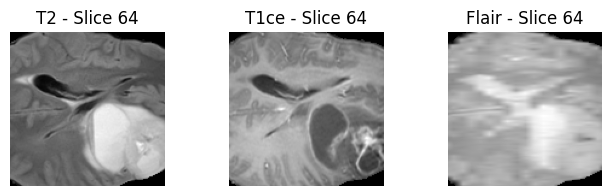

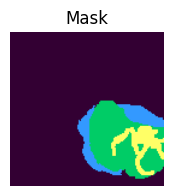

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import torch


for batch in train_loader:
    image, label = batch["image"], batch["label"]
    break  # Take only one batch

# Convert tensors to numpy arrays
image_np = image[0].cpu().numpy()  # Shape: (3, H, W, D)
label_np = label[0].cpu().numpy()  # Shape: (4, H, W, D)
print(np.max(image_np))
print(np.max(label_np))
# Choose a middle slice
slice_idx = image_np.shape[-1] // 2

# Custom color map for BraTS labels
brats_cmap = {
    0: (51, 0, 51),  # Background - Violet
    1: (0, 204, 102),    # Necrotic core - green
    2: (51, 153, 255),  # Edema - blue
    3: (255, 255, 102)     # Enhancing tumor - yellow
}


fig, axes = plt.subplots(1, 3, figsize=(8, 2))
modality_names = ["T2", "T1ce", "Flair"]

for i in range(3):
    axes[i].imshow(image_np[i, :, :, slice_idx], cmap="gray")
    axes[i].set_title(f"{modality_names[i]} - Slice {slice_idx}")
    axes[i].axis("off")
    # print(np.max(image_np[i, :, :, slice_idx]))

plt.show()

label_rgb_smooth = np.zeros((*label_np.shape[1:3], 3), dtype=np.float32)

for class_idx, color in brats_cmap.items():
    prob_map = label_np[class_idx, :, :, slice_idx]
    label_rgb_smooth += np.expand_dims(prob_map, axis=-1) * np.array(color, dtype=np.float32)

# Normalize and convert to uint8
label_rgb_smooth = np.clip(label_rgb_smooth, 0, 255).astype(np.uint8)

plt.figure(figsize=(2, 2))
plt.imshow(label_rgb_smooth, interpolation='bilinear')
plt.title("Mask")
plt.axis("off")
plt.show()


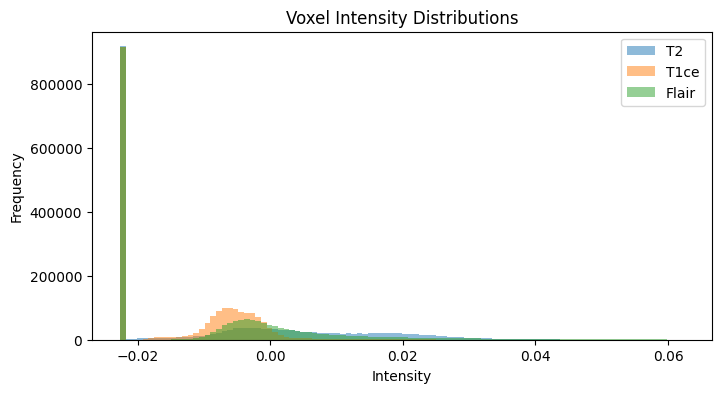

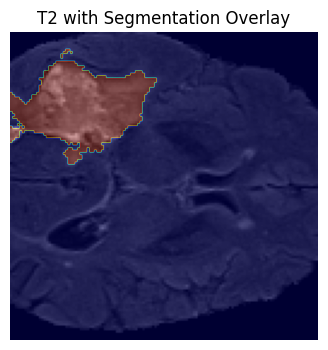

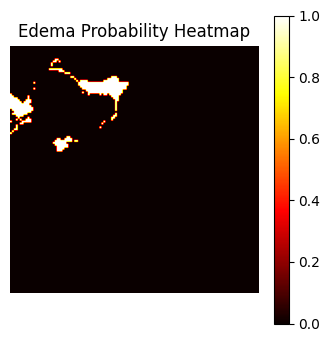

T2: mean=-0.01, std=0.02, min=-0.02, max=0.06
T1ce: mean=-0.01, std=0.01, min=-0.02, max=0.06
Flair: mean=-0.01, std=0.02, min=-0.02, max=0.06
Background: mean probability=0.9619, max probability=1.0000
Necrotic core: mean probability=0.0032, max probability=1.0000
Edema: mean probability=0.0203, max probability=1.0000
Enhancing tumor: mean probability=0.0147, max probability=1.0000


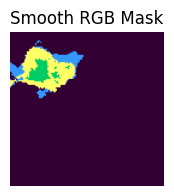

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assume batch loading already done
for batch in train_loader:
    image, label = batch["image"], batch["label"]
    break

image_np = image[0].cpu().numpy()  # (3, H, W, D)
label_np = label[0].cpu().numpy()  # (4, H, W, D)
slice_idx = image_np.shape[-1] // 2

# --- 1. Histogram of voxel intensities
plt.figure(figsize=(8,4))
for i in range(3):
    plt.hist(image_np[i].flatten(), bins=100, alpha=0.5, label=f"{modality_names[i]}")
plt.title("Voxel Intensity Distributions")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# --- 2. Overlay segmentation mask on T2 scan
t2_slice = image_np[0, :, :, slice_idx]
mask_overlay = np.max(label_np[1:, :, :, slice_idx], axis=0)  # skip background

plt.figure(figsize=(4,4))
plt.imshow(t2_slice, cmap='gray')
plt.imshow(mask_overlay, cmap='jet', alpha=0.4)
plt.title("T2 with Segmentation Overlay")
plt.axis("off")
plt.show()

# --- 3. Probability heatmap for edema (class 2)
edema_prob = label_np[2, :, :, slice_idx]
plt.figure(figsize=(4,4))
plt.imshow(edema_prob, cmap="hot")
plt.title("Edema Probability Heatmap")
plt.axis("off")
plt.colorbar()
plt.show()

# --- 4. Simple statistics
for i, name in enumerate(modality_names):
    data = image_np[i]
    print(f"{name}: mean={data.mean():.2f}, std={data.std():.2f}, min={data.min():.2f}, max={data.max():.2f}")

for j, class_name in enumerate(["Background", "Necrotic core", "Edema", "Enhancing tumor"]):
    prob = label_np[j]
    print(f"{class_name}: mean probability={prob.mean():.4f}, max probability={prob.max():.4f}")

# --- 5. Keep your original smooth RGB mask
label_rgb_smooth = np.zeros((*label_np.shape[1:3], 3), dtype=np.float32)
for class_idx, color in brats_cmap.items():
    prob_map = label_np[class_idx, :, :, slice_idx]
    label_rgb_smooth += np.expand_dims(prob_map, axis=-1) * np.array(color, dtype=np.float32)

label_rgb_smooth = np.clip(label_rgb_smooth, 0, 255).astype(np.uint8)
plt.figure(figsize=(2, 2))
plt.imshow(label_rgb_smooth, interpolation='bilinear')
plt.title("Smooth RGB Mask")
plt.axis("off")
plt.show()
